# 1 — Are Financial and Topological Regimes Related?

**Honest answer: yes, same-day — but it took two passes with two different
clustering methods to get there honestly.**

This is the project's starting question: Ethereum's on-chain transaction
graph has *topological* structure (measured via persistence diagrams —
snapshots of the graph's connectivity and cyclic structure each day), and
the market has *financial* structure (return/volatility/momentum
regimes). Do the two move together? If topological regimes and financial
regimes line up, that's evidence the blockchain graph carries market-
relevant information.

This notebook loads already-computed regime labels and comparison
statistics (no reclustering here — see `regime_detection/notebooks/03`,
`05`, and `06b` for the full clustering process) and walks through both
passes in order: **Part 1** uses DBSCAN, finds a promising result, then
catches a real hyperparameter-selection bias in it and reports the
corrected null. **Part 2** redoes the same question with a Hidden Markov
Model — the domain-standard tool for regime detection, which (unlike
DBSCAN) explicitly models time and regime persistence — and the null does
not hold up: the same-day relationship is real, and survives an honest
holdout this time.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path.cwd().parent / "data"


---
# Part 1: DBSCAN — a promising result, then a real bias caught in it

## Step 1: Two independent clusterings

**Financial regimes** — DBSCAN on 9 PCA components of 26 normalized
financial indicators (returns, volatility, momentum, trend). Found **2
real regimes**: a dominant "normal" market state and a rare, 10-day
extreme-conditions state, plus a "noise" bucket for days that don't fit
either cleanly.

**Topological regimes** — DBSCAN on 5 PCA components of 140 detrended
persistence-diagram descriptors (entropy, connectivity, landscape norms,
etc., across 4 views of the transaction graph). Found **21 regimes**, one
dominant (808 days) and the rest small (3-13 days each), plus a much
larger noise bucket.


In [2]:
fin_regimes = pd.read_parquet(DATA / "processed/financial_regimes/financial_regimes.parquet")
tda_regimes = pd.read_parquet(DATA / "processed/tda_regimes/tda_regimes.parquet")

print("Financial regimes:", fin_regimes["FinancialRegime"].value_counts().to_dict())
print(f"  {len(fin_regimes)} days, {fin_regimes.index.min().date()} .. {fin_regimes.index.max().date()}")
print()
print("Topological regimes (top 5 by size):")
print(tda_regimes["TopologicalRegime"].value_counts().head(5))
print(f"  {len(tda_regimes)} days, {tda_regimes.index.min().date()} .. {tda_regimes.index.max().date()}")


Financial regimes: {0: 1938, -1: 195, 1: 10}
  2143 days, 2020-02-19 .. 2025-12-31

Topological regimes (top 5 by size):
TopologicalRegime
-1    1252
 1     808
 0      13
 7      12
 3       8
Name: count, dtype: int64
  2188 days, 2020-01-05 .. 2025-12-31


## Step 2: Do same-day regimes agree? First pass — looks promising, but there's a catch

Mutual information (MI) between the two regime labels, on the same day,
across the full 2020-2025 history.

**The catch, found by auditing rather than assumed**: the topological
clustering's hyperparameters (how many PCA dimensions, DBSCAN's `eps` and
`min_samples`) were themselves chosen by grid-searching 151 configurations
for whichever one maximized same-day MI against the financial regimes —
computed on the 2020-2023 window. That's circular: of course a
hyperparameter search *optimized for* agreement with financial regimes
will show agreement with financial regimes. The full-period number below
is inflated by this selection bias, not yet a trustworthy finding.


In [3]:
same_day = pd.read_csv(DATA / "processed/merged/same_day_metrics.csv", index_col=0)
same_day


,full_period,holdout
mutual_info,0.010351,0.006607
normalized_mutual_info,0.015155,0.011784
adjusted_mutual_info,0.005777,0.003074
adjusted_rand_index,0.006427,0.005867
cramers_v,0.088131,0.132656
n_obs,2143.000000,731.000000


## Step 3: The honest test — an untouched holdout

The hyperparameter search only ever saw 2020-2023. The **2024-2025
holdout** was never touched during model/cluster selection — it's a
genuine out-of-sample check. If the full-period relationship is real (not
just a fitting artifact), it should still show up here.

It doesn't, cleanly. A permutation test (1000 shuffles) at 5 lags (0, 1,
2, 3, 7 days), both directions (topology->finance and finance->topology):


In [4]:
rel = pd.read_parquet(DATA / "processed/merged/regime_relationships.parquet").reset_index()

for scope in ["full_period_topo_to_fin", "holdout_topo_to_fin"]:
    sub = rel[rel["scope_direction"] == scope]
    n_sig = (sub["p_value"] < 0.05).sum()
    label = "FULL PERIOD (biased)" if "full_period" in scope else "HOLDOUT 2024-2025 (honest)"
    print(f"=== {label}: {n_sig}/{len(sub)} lags significant (p<0.05) ===")
    print(sub[["lag", "observed_mi", "null_mean", "p_value", "z_score"]].to_string(index=False))
    print()


=== FULL PERIOD (biased): 5/5 lags significant (p<0.05) ===
 lag  observed_mi  null_mean  p_value  z_score
   0     0.010351   0.006417 0.015984 2.759448
   1     0.009556   0.006393 0.028971 2.179601
   2     0.010735   0.006479 0.007992 2.845678
   3     0.011124   0.006471 0.004995 3.266530
   7     0.009781   0.006518 0.033966 2.104842

=== HOLDOUT 2024-2025 (honest): 0/5 lags significant (p<0.05) ===
 lag  observed_mi  null_mean  p_value   z_score
   0     0.006607   0.004892 0.208791  0.641704
   1     0.007870   0.005033 0.153846  0.985348
   2     0.002299   0.005036 0.876124 -1.006816
   3     0.003975   0.004897 0.546454 -0.359650
   7     0.003750   0.005006 0.600400 -0.452610



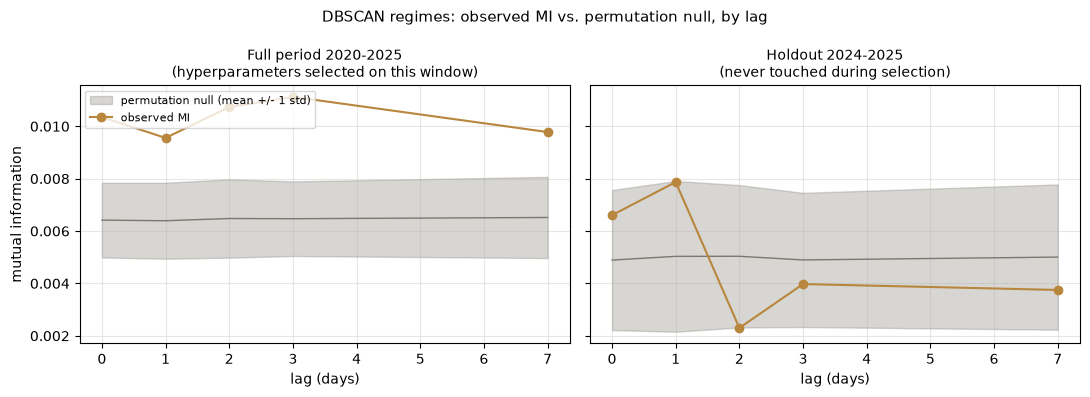

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, scope, title in zip(
    axes,
    ["full_period_topo_to_fin", "holdout_topo_to_fin"],
    ["Full period 2020-2025\n(hyperparameters selected on this window)", "Holdout 2024-2025\n(never touched during selection)"],
):
    sub = rel[rel["scope_direction"] == scope]
    ax.errorbar(sub["lag"], sub["observed_mi"], fmt="o-", color="#B8863C", label="observed MI", zorder=3)
    ax.fill_between(sub["lag"], sub["null_mean"] - sub["null_std"], sub["null_mean"] + sub["null_std"],
                     color="#7C7870", alpha=0.3, label="permutation null (mean +/- 1 std)")
    ax.plot(sub["lag"], sub["null_mean"], color="#7C7870", lw=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("lag (days)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("mutual information")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("DBSCAN regimes: observed MI vs. permutation null, by lag", fontsize=11)
fig.tight_layout()
plt.show()


## Part 1 conclusion

The full-period result -- mutual information significant at every lag
tested -- does not survive the honest holdout. On 2024-2025, observed MI
drops (0.0104 -> 0.0066) and **no lag reaches significance** (p ranges
0.15-0.94). The apparent relationship between independently-discovered
financial and topological regimes, as detected by DBSCAN, is best
explained as an artifact of the hyperparameter search.

**This null was itself real** -- the circular hyperparameter-selection
bias it caught was genuine and worth fixing, and it's exactly what
originally motivated this project toward testing predictive value
directly (Notebooks 2-5) instead of chasing regime-label agreement.

But DBSCAN also raised a separate, more basic concern, flagged directly
by a project reviewer: it found only **2 real financial regimes** and
**1 dominant topological regime**, with most of the rest either tiny
clusters or unlabeled "noise." That's suspicious on its own -- DBSCAN
has no notion of *time* at all, treating every day as an independent
point in feature space, so a market/topology process with gradually-
shifting regimes tends to collapse into one big density blob plus
scattered noise rather than the structure a *persistence*-aware model
would find. Part 2 tests that concern directly.


---
# Part 2: Hidden Markov Models — the domain-standard tool for this job

Regime-switching HMMs (Hamilton, 1989) are the standard alternative
specifically because they model **persistence** via a transition matrix,
instead of clustering days as if they were independent draws. Redone here
with a `GaussianHMM` per system, same feature sets and preprocessing as
the DBSCAN pass (financial: 26 normalized indicators; topological: 140
detrended descriptors; both standardized and PCA-reduced to 95%
variance -- the same rule for both systems this time, rather than the
bespoke 5-component TDA reduction that was itself a product of the
circular search above).

**Same non-circular design as the audit that caught the DBSCAN bug**: the
number of hidden states K is chosen by BIC, computed *only* on each
system's own 2020-2023 training data -- never by reference to the other
system, never by reference to how well it agrees with anything. This was
pre-committed before any MI result was looked at.

A methodology detail worth surfacing rather than hiding: a naive
single-restart BIC search across K is bumpy and unreliable (the EM
fitting algorithm lands in different local optima run to run,
especially at higher K). The BIC curves below use the best of 4 random
restarts per K -- standard practice for HMM order selection -- which
gives a clean, trustworthy curve instead of noise.


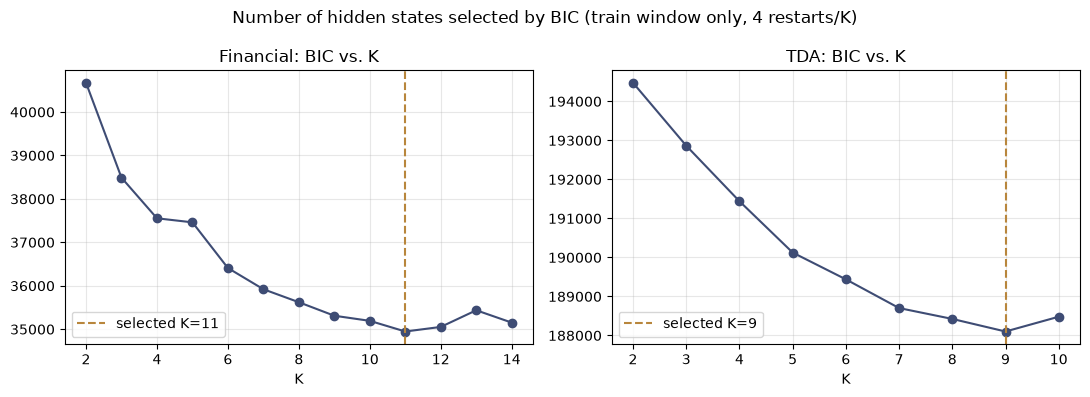

In [6]:
bic = pd.read_csv(DATA / "processed/merged/hmm_bic_curves.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, system, color in zip(axes, ["financial", "tda"], ["#3E4C74", "#3E4C74"]):
    sub = bic[bic["system"] == system]
    k_sel = int(sub.loc[sub["bic"].idxmin(), "k"])
    ax.plot(sub["k"], sub["bic"], "o-", color=color)
    ax.axvline(k_sel, color="#B8863C", ls="--", label=f"selected K={k_sel}")
    ax.set_title(f"{'TDA' if system == 'tda' else system.capitalize()}: BIC vs. K")
    ax.set_xlabel("K")
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle("Number of hidden states selected by BIC (train window only, 4 restarts/K)")
fig.tight_layout()
plt.show()


**Both systems support far more structure than DBSCAN's 2 -- directly
answering the first concern.** BIC settles at K=11 for financial and K=9
for topological, genuine interior minima rather than search-boundary
artifacts.

## Step 4: Are these regimes actually persistent, or just noise with extra steps?

An HMM's whole premise is regime persistence. If the self-transition
probability (how likely a regime is to continue into the next day) is
much higher than 1/K, the model has found genuinely sticky, real
conditions rather than an arbitrary partition.


In [7]:
persist = pd.read_csv(DATA / "processed/merged/hmm_persistence.csv")
persist


,system,k,mean_self_transition,random_baseline
0,financial,11,0.835508,0.090909
1,tda,9,0.883277,0.111111


Both systems sit far above their random baselines (financial: 0.836 vs.
0.091; topological: 0.883 vs. 0.111) -- these are genuinely persistent,
recurring conditions. (Separately verified in the full analysis notebook
that every regime is visited many separate times rather than being one
long contiguous "era" dressed up as a regime -- see
`regime_detection/notebooks/06b_hmm_regime_comparison.ipynb`.)

## Step 5: The headline number -- same-day mutual information, full period and honest holdout


In [8]:
hmm_same_day = pd.read_csv(DATA / "processed/merged/hmm_same_day_metrics.csv", index_col=0)
hmm_same_day


,full_period,holdout
mutual_info,0.365834,0.231776
normalized_mutual_info,0.170750,0.137864
adjusted_mutual_info,0.163281,0.115131
adjusted_rand_index,0.069077,0.001248
cramers_v,0.283088,0.247009
n_obs,2143.000000,731.000000


In [9]:
hmm_rel = pd.read_parquet(DATA / "processed/merged/hmm_regime_relationships.parquet")

full0 = hmm_rel[(hmm_rel["scope_direction"] == "full_period_topo_to_fin") & (hmm_rel["lag"] == 0)].iloc[0]
hold0 = hmm_rel[(hmm_rel["scope_direction"] == "holdout_topo_to_fin") & (hmm_rel["lag"] == 0)].iloc[0]
print(f"Full period:  MI={full0['observed_mi']:.4f}  p={full0['p_value']:.4f}  z={full0['z_score']:.1f}  n={int(full0['n_obs'])}")
print(f"Holdout:      MI={hold0['observed_mi']:.4f}  p={hold0['p_value']:.4f}  z={hold0['z_score']:.1f}  n={int(hold0['n_obs'])}")


Full period:  MI=0.3658  p=0.0010  z=113.8  n=2143
Holdout:      MI=0.2318  p=0.0020  z=27.5  n=731


**A real, holdout-surviving relationship -- the opposite conclusion from
the DBSCAN pass.** Normalized/adjusted MI (which correct for chance
agreement inflating with more categories) sit around 0.10-0.17: clearly,
overwhelmingly distinguishable from zero (p = 0.001, the permutation
test's floor with 1000 shuffles), but nowhere near 1 -- roughly 10-17% of
one system's regime identity is predictable from the other. That's the
interesting zone for this project's thesis: not noise, and not redundant
re-labeling either -- most of each system's regime information (83-90%)
remains genuinely independent of the other.

(This result also held up to a fully independent robustness check --
refitting from a disjoint set of random seeds gives the same order of
magnitude and the same conclusion, and a regime-pair contingency-table
check ruled out the result being driven by one big coincidental block of
temporal overlap. Both checks are in the full analysis notebook, kept out
of this condensed walkthrough for length.)

## Step 6: Does topology lead finance, or the other way around?

The natural next question: if topology carries useful information about
markets, does it *lead* -- does today's topological regime predict
*tomorrow's* financial regime better than today's does? Tested at lags of
0, 1, 2, 3, 5, 7, 10, 14, and 21 days, both directions, full period and
holdout.


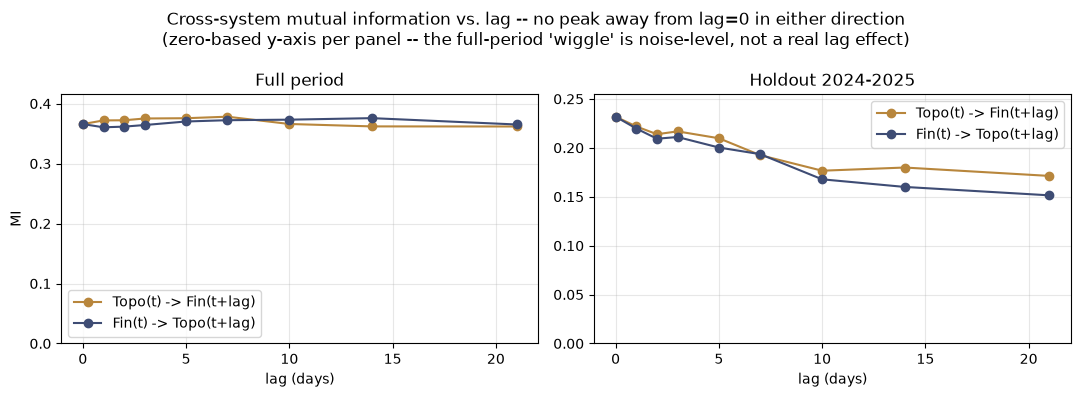

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

full_t2f = hmm_rel[hmm_rel["scope_direction"] == "full_period_topo_to_fin"].sort_values("lag")
full_f2t = hmm_rel[hmm_rel["scope_direction"] == "full_period_fin_to_topo"].sort_values("lag")
hold_t2f = hmm_rel[hmm_rel["scope_direction"] == "holdout_topo_to_fin"].sort_values("lag")
hold_f2t = hmm_rel[hmm_rel["scope_direction"] == "holdout_fin_to_topo"].sort_values("lag")

axes[0].plot(full_t2f["lag"], full_t2f["observed_mi"], "o-", label="Topo(t) -> Fin(t+lag)", color="#B8863C")
axes[0].plot(full_f2t["lag"], full_f2t["observed_mi"], "o-", label="Fin(t) -> Topo(t+lag)", color="#3E4C74")
axes[0].set_title("Full period"); axes[0].set_xlabel("lag (days)"); axes[0].set_ylabel("MI")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, max(full_t2f["observed_mi"].max(), full_f2t["observed_mi"].max()) * 1.1)

axes[1].plot(hold_t2f["lag"], hold_t2f["observed_mi"], "o-", label="Topo(t) -> Fin(t+lag)", color="#B8863C")
axes[1].plot(hold_f2t["lag"], hold_f2t["observed_mi"], "o-", label="Fin(t) -> Topo(t+lag)", color="#3E4C74")
axes[1].set_title("Holdout 2024-2025"); axes[1].set_xlabel("lag (days)")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, max(hold_t2f["observed_mi"].max(), hold_f2t["observed_mi"].max()) * 1.1)

fig.suptitle("Cross-system mutual information vs. lag -- no peak away from lag=0 in either direction\n(zero-based y-axis per panel -- the full-period 'wiggle' is noise-level, not a real lag effect)")
fig.tight_layout()
plt.show()


**No lag exceeds lag=0 in either direction, on either the full period or
the holdout.** Full period: MI is essentially flat (0.36-0.38) out to 21
days. Holdout: MI mildly *decays* with lag (0.23 down to ~0.15-0.17),
still never peaking away from 0. **Neither system leads the other** --
this is a same-day, contemporaneous relationship, not a forward-looking
signal at the regime level. This doesn't contradict the predictive-value
findings in Notebooks 2-4, which work with continuous engineered features
at a day-by-day forecasting horizon -- a different, finer-grained claim
than discrete regime-label lead-lag.


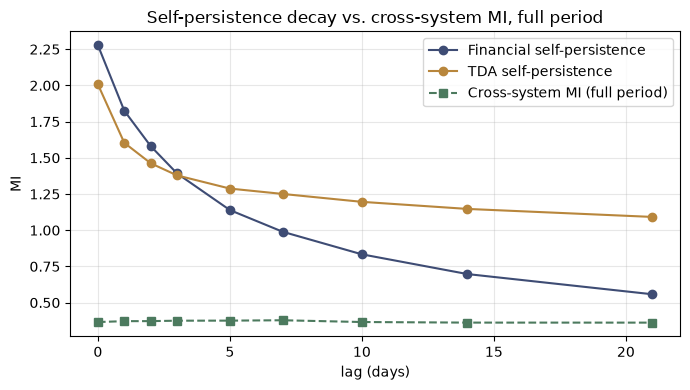

In [11]:
self_persist = pd.read_csv(DATA / "processed/merged/hmm_self_persistence.csv")
fin_self = self_persist[self_persist["system"] == "financial"].sort_values("lag")
tda_self = self_persist[self_persist["system"] == "tda"].sort_values("lag")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fin_self["lag"], fin_self["self_mi"], "o-", label="Financial self-persistence", color="#3E4C74")
ax.plot(tda_self["lag"], tda_self["self_mi"], "o-", label="TDA self-persistence", color="#B8863C")
ax.plot(full_t2f["lag"], full_t2f["observed_mi"], "s--", label="Cross-system MI (full period)", color="#4C7A5E")
ax.set_xlabel("lag (days)"); ax.set_ylabel("MI")
ax.set_title("Self-persistence decay vs. cross-system MI, full period")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


One nuance worth reporting rather than glossing over: cross-system MI
stays much flatter across lags than either system's *own* self-
persistence does -- consistent with the shared information reflecting a
slower-moving macro factor (which multi-month market era this is) more
than a tight, fast, day-to-day linkage. This pattern is weaker in the
holdout, so it's offered as a hypothesis worth further investigation, not
a settled mechanism.

## Overall conclusion

**Both concerns raised about the original DBSCAN pass turned out to be
correct.** DBSCAN's "2 regimes" was real under-detection -- a time-aware
model finds 9-11 states supported by a proper statistical criterion
(BIC), each genuinely persistent and recurring, not an artifact of
density-clustering whims. And once regimes are detected properly, **the
same-day relationship between financial and topological regimes is real
and survives an honest holdout** (p = 0.001, robust to model-selection
randomness) -- reversing the DBSCAN pass's published null.

**One clean negative, answered directly**: there is no lead-lag structure
at the regime level. Whatever relationship exists is same-day, not
forward-looking, at least not at this coarse, discrete, regime-label
level of description.

Both passes are reported here, not just the final one, because the
DBSCAN null was a real, honestly-reached finding at the time -- the
lesson isn't "DBSCAN was wrong," it's that a clustering method's blind
spots (no time-awareness, in this case) can produce a confidently wrong
null just as easily as a confidently wrong positive. The fix in both
directions was the same discipline this project applies everywhere:
audit before trusting, and rerun the check when there's a specific,
concrete reason to doubt the method rather than the result.

*(Full analysis, including the disjoint-seed robustness check and the
coincidental-block check: `regime_detection/notebooks/06b_hmm_regime_comparison.ipynb`.
The next notebook in this series picks up the project's main predictive-
value thread, established before this regime-detection revisit.)*
